In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar los datos limpios
train_df = pd.read_csv('../03_datasets/train_data_prepared.csv')
val_df = pd.read_csv('../03_datasets/val_data_prepared.csv')
test_df = pd.read_csv('../03_datasets/test_data_prepared.csv')

# ¡Eliminamos AMBOS precios de las características (X) para evitar trampas!
columnas_a_borrar = ['buy_price_log', 'rent_price']

X_train = train_df.drop(columnas_a_borrar, axis=1)
y_train = train_df['rent_price']  # <--- ¡AQUÍ ESTÁ EL GRAN CAMBIO!

X_val = val_df.drop(columnas_a_borrar, axis=1)
y_val = val_df['rent_price']      # <--- Cambio aquí también

X_test = test_df.drop(columnas_a_borrar, axis=1)
y_test = test_df['rent_price']    # <--- Y aquí

print(f"Forma de X_train: {X_train.shape}")


Forma de X_train: (11454, 16)


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# 1. Arquitectura
model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),

    Dense(1)                                   # Salida lineal para regresión
])

# 2. Compilar con learning rate explícito
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mae',
    metrics=['mae']
)

# 3. Callbacks mejorados
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

# 4. Entrenar con más épocas
print("Iniciando el entrenamiento de la Red Neuronal...\n")

fit_params = {
    "validation_data": (X_val, y_val),
    "epochs": 500,
    "batch_size": 32,
    "callbacks": [early_stop, reduce_lr],
    "verbose": 1
}

history = model.fit(
    X_train, y_train,**fit_params
)


Iniciando el entrenamiento de la Red Neuronal...

Epoch 1/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1232.2654 - mae: 1232.2654 - val_loss: 980.3019 - val_mae: 980.3019 - learning_rate: 0.0010
Epoch 2/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - loss: 574.8368 - mae: 574.8368 - val_loss: 335.9960 - val_mae: 335.9960 - learning_rate: 0.0010
Epoch 3/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 363.2547 - mae: 363.2547 - val_loss: 343.2622 - val_mae: 343.2622 - learning_rate: 0.0010
Epoch 4/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 326.3618 - mae: 326.3618 - val_loss: 228.3877 - val_mae: 228.3877 - learning_rate: 0.0010
Epoch 5/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 313.0363 - mae: 313.0363 - val_loss: 208.8800 - val_mae: 208.8800 - learning_rate: 0.0010
Epoch 6/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 296.9705 - mae: 296.9705 - val_loss: 230.9876 - val_mae: 230.9876 - learning_rate: 0.0010
Epoch 7/500
358/358 ━━━━━━━━━━━━━━━━━━━━

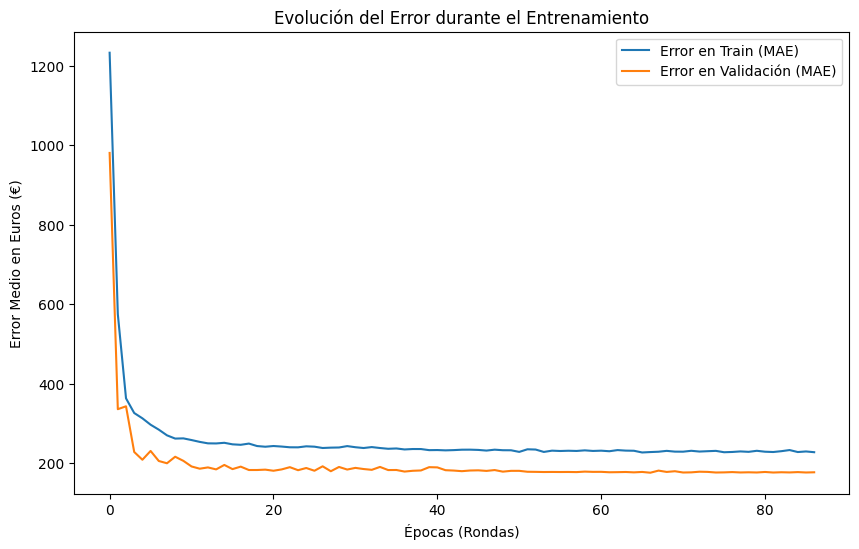

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 627us/step

--- RESULTADOS FINALES DE ALQUILER EN TEST ---
Error Absoluto Medio (MAE): 177.29 €/mes
R-Cuadrado (R2): 0.7654


In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Ver cómo ha aprendido la red con un gráfico
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Error en Train (MAE)')
plt.plot(history.history['val_loss'], label='Error en Validación (MAE)')
plt.title('Evolución del Error durante el Entrenamiento')
plt.xlabel('Épocas (Rondas)')
plt.ylabel('Error Medio en Euros (€)')
plt.legend()
plt.show()

# 1. Hacer predicciones sobre los datos de TEST
predicciones_test = model.predict(X_test)

# 2. Calcular métricas finales (Directamente, sin conversiones)
mae = mean_absolute_error(y_test, predicciones_test)
r2 = r2_score(y_test, predicciones_test)

print("\n--- RESULTADOS FINALES DE ALQUILER EN TEST ---")
print(f"Error Absoluto Medio (MAE): {mae:,.2f} €/mes")
print(f"R-Cuadrado (R2): {r2:.4f}")

In [17]:
params = {
    "batch_size":fit_params["batch_size"],
    "epochs":fit_params["epochs"],
}

record = pd.read_csv("../models/models_log.csv")

val_r2 = r2_score(y_val, model.predict(X_val))
val_mae = mean_absolute_error(y_val, model.predict(X_val))

rent_r2 = record.loc[record["model"] == "rent_model", "r2"]
record_r2_log = 0 if rent_r2.empty or rent_r2.isna().all() else rent_r2.max()

if val_r2 > record_r2_log:
    model_type = "rent_model_DL",
    model_name = "modelo_alquiler_dl.keras",
    best_params = params,
    best_r2 = val_r2,
    best_mae = val_mae

    entry = {
        "model": "rent_model",
        "model_type": model_type,
        "model_name": model_name,
        "r2": best_r2,
        "mae": best_mae,
    }

    entry_df = pd.DataFrame(entry, index=[0])
    params_str = str(best_params)
    entry_df["params"] = params_str

    new_record = pd.concat([record, entry_df], ignore_index=True)

    new_record.to_csv("../models/models_log.csv", index=False)
    # 1. Guardar el modelo de la Red Neuronal (El "Cerebro")
    model.save('../models/modelo_alquiler_dl.keras')
    
    print(f"✅ Modelo de Red Neuronal guardado como {model_name}")
    print("\n¡Todo empaquetado y listo!")

else:
    print("No se mejoró el modelo. No se guardará.")






118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step
✅ Modelo de Red Neuronal guardado como ('modelo_alquiler_dl.keras',)

¡Todo empaquetado y listo!


/tmp/ipykernel_75267/822325135.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_record = pd.concat([record, entry_df], ignore_index=True)
